In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
wo = []
w_device_mem = []
w_host_mem = []

for i in range(0, 6):
    bs = 2 ** i
    wo_cur, w_device_cur, w_host_cur = [], [], []
    for j in range(1, 11):
        filename = f"results_same_lba/iter_1000_each30_bs_{bs}_run_{j}.txt"
        with open(filename, "r") as f:
            f.readline()
            wo_l = f.readline()
            wd_l = f.readline()
            wh_l = f.readline()
            wo_cur.append(float(wo_l.split()[-2]))
            w_device_cur.append(float(wd_l.split()[-2]))
            w_host_cur.append(float(wh_l.split()[-2]))
    wo.append(wo_cur)
    w_device_mem.append(w_device_cur)
    w_host_mem.append(w_host_cur)

In [3]:
wo_avg = [np.average(x) for x in wo]
wd_avg = [np.average(x) for x in w_device_mem]
wh_avg = [np.average(x) for x in w_host_mem]

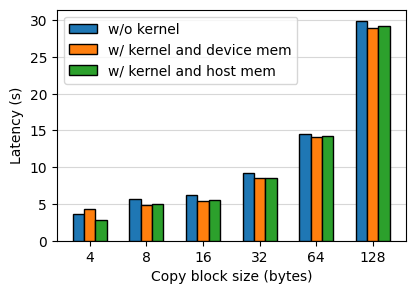

In [4]:
# Use plt to draw a bar chart, x is 1, 2, 4, 8, 16, 32. Each entry has three values from wo_avg, wd_avg and wh_avg
plt.figure(figsize=(4.5, 3))

x = np.arange(0, 6)

plt.bar([i - 0.2 for i in x], wo_avg, edgecolor='black', width=0.2, label='w/o kernel', zorder=3)
plt.bar(x, wd_avg, edgecolor='black', width=0.2, label='w/ kernel and device mem', zorder=3)
plt.bar([i + 0.2 for i in x], wh_avg, edgecolor='black', width=0.2, label='w/ kernel and host mem', zorder=3)

plt.xticks(x, ('4', '8', '16', '32', '64', '128'))
plt.xlabel('Copy block size (bytes)')
plt.ylabel('Latency (s)')

plt.legend()

plt.grid(axis='y', alpha=0.5, zorder=0)

plt.savefig("copy_same_lba.pdf", bbox_inches='tight')


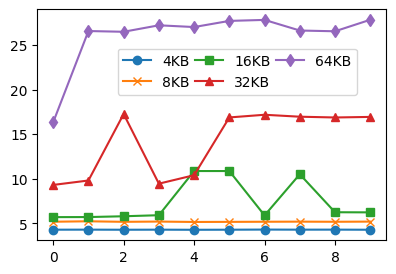

In [45]:
plt.figure(figsize=(4.5, 3))

labels = ["o", "x", "s", "^", "d"]

for i in range(5):
    plt.plot(np.arange(10), w_device_mem[i], marker=labels[i], label=f"{2 ** (i + 2)}KB")

plt.legend(ncol=3, frameon=True, columnspacing=0.4, loc=(0.23, 0.63))

In [ ]:
# Read w_device_mem into a table, headers are 4KB, 8KB, 16KB, 32KB, 64KB

import pandas as pd
df = pd.DataFrame(w_device_mem, columns=['4KB', '8KB', '16KB', '32KB', '64KB'])